In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [19]:

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

(8693, 14) (4277, 13)
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


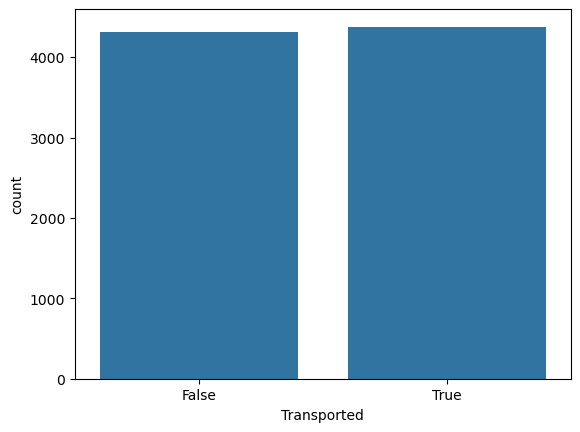

In [20]:

print(train_df.shape, test_df.shape)
print(train_df.isnull().sum())
sns.countplot(x="Transported", data=train_df)
plt.show()

In [21]:
train_df["isTrain"] = 1
test_df["isTrain"] = 0
test_df["Transported"] = np.nan

combined = pd.concat([train_df, test_df]).reset_index(drop=True)

In [22]:
cabin_split = combined["Cabin"].str.split("/", expand=True)
combined["Deck"] = cabin_split[0].fillna("Unknown")
combined["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
combined["Side"] = cabin_split[2].fillna("Unknown")

In [23]:
expense_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]
combined[expense_cols] = combined[expense_cols].fillna(0)
combined["TotalSpending"] = combined[expense_cols].sum(axis=1)
combined["HasSpent"] = (combined["TotalSpending"] > 0).astype(int)
combined["NumServices"] = (combined[expense_cols] > 0).sum(axis=1)
combined["LuxurySpending"] = combined["Spa"] + combined["VRDeck"]
combined["BasicSpending"] = combined["RoomService"] + combined["FoodCourt"] + combined["ShoppingMall"]
combined["SpendingRatio"] = combined["LuxurySpending"] / (combined["TotalSpending"] + 1)

In [24]:
combined["PassengerGroup"] = combined["PassengerId"].str.split("_").str[0]
combined["GroupSize"] = combined.groupby("PassengerGroup")["PassengerId"].transform("count")
combined["IsAlone"] = (combined["GroupSize"] == 1).astype(int)

In [25]:
combined["HomePlanet"].fillna(combined["HomePlanet"].mode()[0], inplace=True)
combined["Destination"].fillna(combined["Destination"].mode()[0], inplace=True)
combined["Age"].fillna(combined["Age"].median(), inplace=True)
combined["CryoSleep"].fillna(False, inplace=True)
combined["VIP"].fillna(False, inplace=True)

In [26]:
le = LabelEncoder()
cat_cols = ["HomePlanet","Destination","Deck","Side"]
for col in cat_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

combined["CryoSleep"] = combined["CryoSleep"].astype(int)
combined["VIP"] = combined["VIP"].astype(int)

In [27]:
features = [
    "HomePlanet","Destination","Deck","Side","CryoSleep","VIP","Age","CabinNum",
    "RoomService","FoodCourt","ShoppingMall","Spa","VRDeck","TotalSpending",
    "HasSpent","NumServices","GroupSize","IsAlone","LuxurySpending",
    "BasicSpending","SpendingRatio"
]

X = combined[combined["isTrain"]==1][features]
y = combined[combined["isTrain"]==1]["Transported"].astype(int)
X_test = combined[combined["isTrain"]==0][features]

In [28]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [300, 400, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

grid_search = RandomizedSearchCV(
    xgb, param_grid, n_iter=10, cv=5, scoring='accuracy', verbose=1, random_state=42
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
val_pred = best_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Validation Accuracy: 0.7964347326049454
Best Parameters: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [31]:
best_model.fit(X, y)
test_pred = best_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": test_pred.astype(bool)
})
submission.to_csv("submission.csv", index=False)
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
